In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Raw data load
df = pd.read_csv('/content/heart_disease_health_indicators_BRFSS2015 (1).csv')

print("Data Shape:", df.shape)
df.head()

Data Shape: (253680, 22)


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


# Phase 1: Environment Setup & Data Loading

## Overview
In this initial step, we set up the data science environment by importing the required libraries for data analysis, visualization, and preprocessing. We then load the raw dataset to inspect its structure and dimensions before starting the preprocessing pipeline.

### Steps Performed:
1. **Import Libraries:** `pandas`, `numpy`, `matplotlib`, `seaborn`, and `scikit-learn` modules.
2. **Load Dataset:** Load the `heart_disease_health_indicators_BRFSS2015.csv` file from the raw data directory.
3. **Initial Inspection:** Verify the shape (rows and columns) and preview the top rows of the dataset.


# Phase 2: Train-Test Split (Preventing Data Leakage)

## Overview
Before applying any data imputation, transformation, or cleaning, we split the dataset into Training (80%) and Testing (20%) sets.

### Why Split First?
Fitting imputation or scaling parameters on the full dataset before splitting leads to **data leakage**, resulting in overly optimistic model evaluations. By splitting early, all preprocessing rules will be learned strictly from the training set.

### Steps Performed:
1. Separate features (`X`) and the target variable (`y = HeartDiseaseorAttack`).
2. Perform an 80/20 train-test split with stratification to maintain target class proportions.

In [ ]:
# Separate target variable from features
X = df.drop(columns=['HeartDiseaseorAttack'])
y = df['HeartDiseaseorAttack']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape:  {X_test.shape}")
print(f"Training Target Class Distribution:\n{y_train.value_counts(normalize=True)}")

Training Features Shape: (202944, 21)
Testing Features Shape:  (50736, 21)
Training Target Class Distribution:
HeartDiseaseorAttack
0.0    0.905816
1.0    0.094184
Name: proportion, dtype: float64


# Phase 3: Data Audit & Cleaning

## Overview
In this step, we perform a thorough data quality audit on the training set (`X_train`) to identify missing values, check summary statistics, and detect duplicate rows or invalid data ranges before proceeding to EDA.

### Steps Performed:
1. Check for missing/null values across all features.
2. Evaluate summary statistics (min, max, mean, standard deviation) for potential anomalies or outliers.
3. Check and remove any duplicate entries from the training set.

In [ ]:
# 1. Missing values check
missing_vals = X_train.isnull().sum()
print("Missing values per column in X_train:")
print(missing_vals[missing_vals > 0] if missing_vals.sum() > 0 else "No missing values found!")

# 2. Check for duplicate rows in training set
duplicates_count = X_train.duplicated().sum()
print(f"\nDuplicate rows in X_train: {duplicates_count}")

# 3. Summary statistics for range/outlier checks
print("\nSummary Statistics of X_train:")
X_train.describe().T[['mean', 'std', 'min', '50%', 'max']]

Missing values per column in X_train:
No missing values found!

Duplicate rows in X_train: 17905

Summary Statistics of X_train:


,mean,std,min,50%,max
HighBP,0.429232,0.494968,0.0,0.0,1.0
HighChol,0.424753,0.494307,0.0,0.0,1.0
CholCheck,0.962773,0.189318,0.0,1.0,1.0
BMI,28.381056,6.610957,12.0,27.0,98.0
Smoker,0.443122,0.496756,0.0,0.0,1.0
Stroke,0.040346,0.196770,0.0,0.0,1.0
Diabetes,0.297353,0.698492,0.0,0.0,2.0
PhysActivity,0.756815,0.429007,0.0,1.0,1.0
Fruits,0.634727,0.481508,0.0,1.0,1.0
Veggies,0.811884,0.390806,0.0,1.0,1.0


# Phase 4: Duplicate Removal & Exploratory Data Analysis (EDA)

## Overview
We remove duplicate rows from the training dataset (`X_train` and `y_train`) to ensure model training relies on unique instances. Following the cleanup, we explore feature distributions, class imbalances in the target variable, and correlations among health indicators.

### Steps Performed:
1. Deduplicate training data synchronized with target labels.
2. Plot target variable distribution (`HeartDiseaseorAttack`).
3. Visualize continuous features (e.g., `BMI`) distribution.
4. Generate a Correlation Heatmap to observe relationships between features.

Shape of X_train after deduplication: (185771, 21)


/tmp/ipykernel_3253/3284397797.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette='coolwarm')


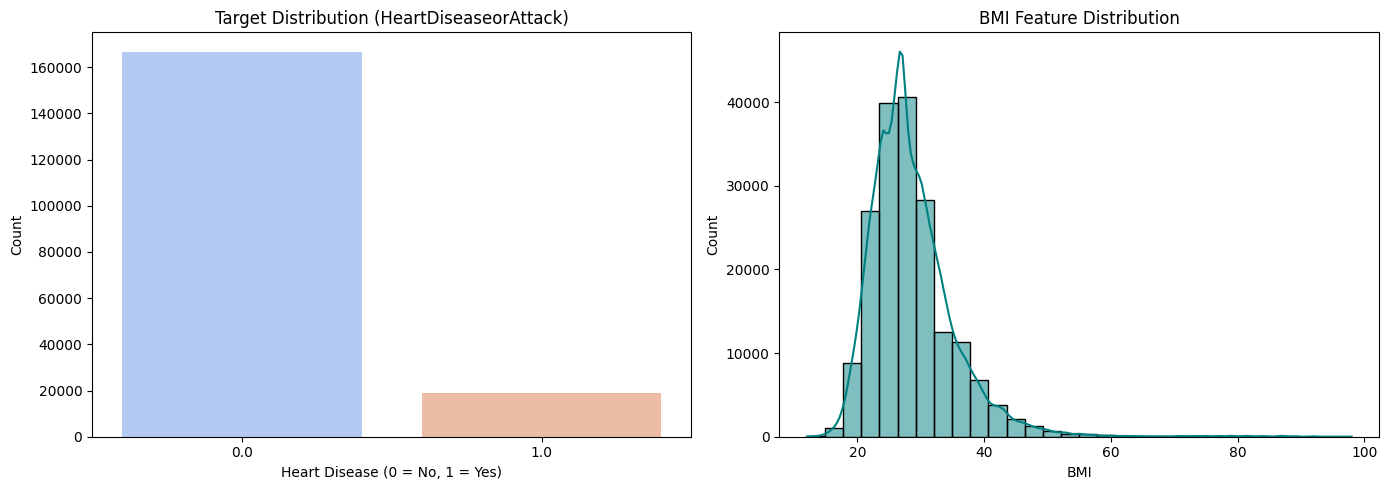

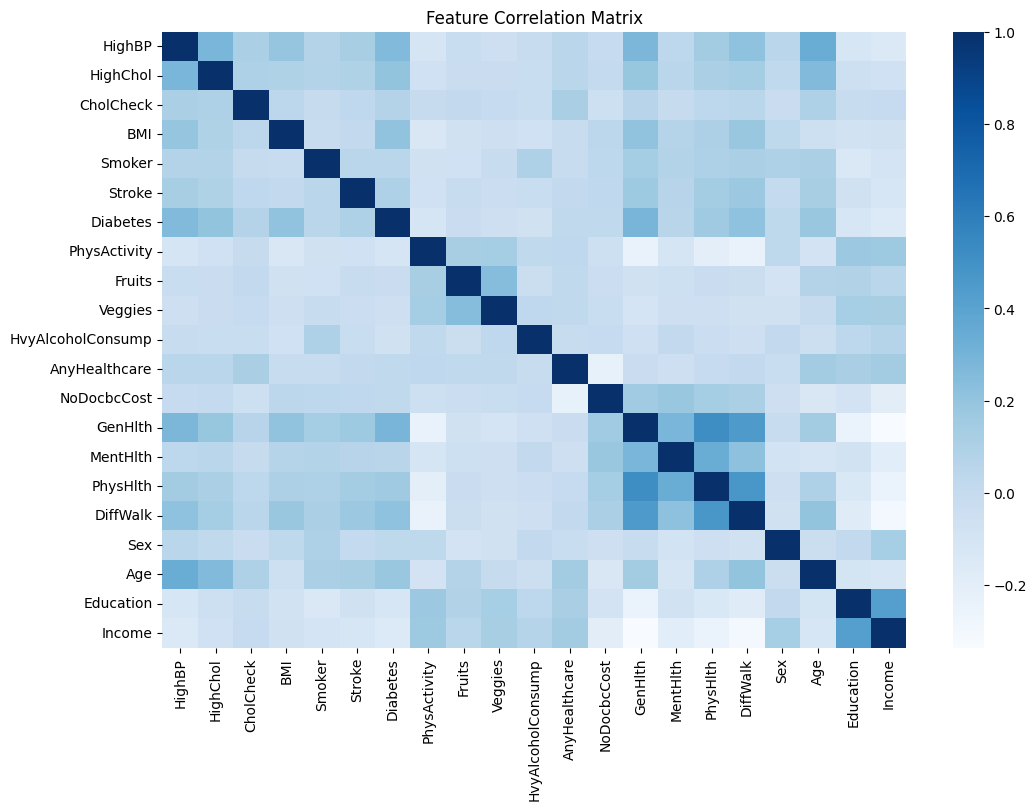

In [ ]:
# 1. Deduplicate X_train and synchronize y_train
train_combined = pd.concat([X_train, y_train], axis=1)
train_combined = train_combined.drop_duplicates()

# Re-split X_train and y_train after deduplication
X_train = train_combined.drop(columns=['HeartDiseaseorAttack'])
y_train = train_combined['HeartDiseaseorAttack']

print(f"Shape of X_train after deduplication: {X_train.shape}")

# 2. EDA Visualizations Setup
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target Variable Distribution
sns.countplot(x=y_train, ax=axes[0], palette='coolwarm')
axes[0].set_title('Target Distribution (HeartDiseaseorAttack)')
axes[0].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')

# BMI Distribution
sns.histplot(X_train['BMI'], kde=True, bins=30, ax=axes[1], color='teal')
axes[1].set_title('BMI Feature Distribution')
axes[1].set_xlabel('BMI')

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(X_train.corr(), cmap='Blues', annot=False, cbar=True)
plt.title('Feature Correlation Matrix')
plt.show()

# Phase 5: Exporting Cleaned & Processed Datasets

## Overview
In this final step, we export the split and cleaned datasets to the `Data/processed/` directory. This ensures that down-stream modeling (e.g., Student 3's task) can directly consume preprocessed data without risk of data leakage.

### Saved Files:
* `X_train_clean.csv` & `y_train_clean.csv`
* `X_test_clean.csv` & `y_test_clean.csv`

In [ ]:
import os

# Processed directory path create karein agar exist nahi karti
processed_dir = '../Data/processed'
os.makedirs(processed_dir, exist_ok=True)

# Datasets export karein
X_train.to_csv(f'{processed_dir}/X_train_clean.csv', index=False)
y_train.to_csv(f'{processed_dir}/y_train_clean.csv', index=False)
X_test.to_csv(f'{processed_dir}/X_test_clean.csv', index=False)
y_test.to_csv(f'{processed_dir}/y_test_clean.csv', index=False)

print("✅ All clean datasets successfully exported to 'Data/processed/' directory!")

✅ All clean datasets successfully exported to 'Data/processed/' directory!


# **Feature Engineering**

# 1. Clinical Composite: Cardiometabolic Risk Score
Aggregates major CDC-recognized cardiometabolic risk factors into a single interpretable score.
Higher values indicate elevated chronic disease burden

In [ ]:
X_train['CardiometabolicRiskScore'] = (
    X_train['HighBP'] +
    X_train['HighChol'] +
    X_train['Diabetes'] +
    X_train['Stroke']
)

X_test['CardiometabolicRiskScore'] = (
    X_test['HighBP'] +
    X_test['HighChol'] +
    X_test['Diabetes'] +
    X_test['Stroke']
)

# 2. Obesity Classification (BMI-Based)
 Converts continuous BMI into a binary clinical obesity flag.

In [ ]:
X_train['ObesityFlag'] = (X_train['BMI'] >= 30).astype(int)

In [ ]:
X_test['ObesityFlag'] = (X_test['BMI'] >= 30).astype(int)

# 3. Tobacco Exposure Index
Combines smoking status and frequency into a single exposure metric.

In [ ]:
# 1 = current smoker, 2 = former smoker
X_train['CurrentSmokerFlag'] = (X_train['Smoker'] == 1).astype(int)
X_train['FormerSmokerFlag'] = (X_train['Smoker'] == 2).astype(int)
X_test['CurrentSmokerFlag'] = (X_test['Smoker'] == 1).astype(int)
X_test['FormerSmokerFlag'] = (X_test['Smoker'] == 2).astype(int)

 # 4. Alcohol Misuse Indicator
Heavy drinking is defined by CDC thresholds. Converts to binary flag.

In [ ]:
X_train['HeavyDrinkFlag'] = (X_train['HvyAlcoholConsump'] == 1).astype(int)
X_test['HeavyDrinkFlag'] = (X_test['HvyAlcoholConsump'] == 1).astype(int)

# 5. Mental Health Burden Score
Aggregates poor mental health days and depression diagnosis.

In [ ]:
X_train['MentalHealthBurden'] = (
    X_train.get('MentHlth', 0) +
    X_train.get('Depressed', 0)
)

X_test['MentalHealthBurden'] = (
    X_test.get('MentHlth', 0) +
    X_test.get('Depressed', 0)
)

# 6. Physical Activity Adequacy
Converts activity level into a binary adequacy flag.

In [ ]:
X_train['PhysicallyActiveFlag'] = (X_train['PhysActivity'] == 1).astype(int)
X_test['PhysicallyActiveFlag'] = (X_test['PhysActivity'] == 1).astype(int)

# 7. Respiratory Risk Composite
Combines asthma and COPD into a single respiratory risk indicator.

In [ ]:
X_train['RespiratoryRiskScore'] = (
    X_train.get('Asthma', 0) +
    X_train.get('COPD', 0)
)

X_test['RespiratoryRiskScore'] = (
    X_test.get('Asthma', 0) +
    X_test.get('COPD', 0)
)

# 8. Hypertension Severity Proxy
Combines high BP with medication status (if available).

In [ ]:
if 'BP_Medication' in X_train.columns:
    X_train['HypertensionSeverity'] = (
        X_train['HighBP'] +
        X_train['BP_Medication']
    )

if 'BP_Medication' in X_test.columns:
    X_test['HypertensionSeverity'] = (
        X_test['HighBP'] +
        X_test['BP_Medication']
    )

# 9.Metabolic Syndrome Proxy
Uses obesity, high BP, high cholesterol, and diabetes.

In [ ]:
X_train['MetabolicSyndromeProxy'] = (
    X_train['ObesityFlag'] +
    X_train['HighBP'] +
    X_train['HighChol'] +
    X_train['Diabetes']
)

X_test['MetabolicSyndromeProxy'] = (
    X_test['ObesityFlag'] +
    X_test['HighBP'] +
    X_test['HighChol'] +
    X_test['Diabetes']
)

# 10. Age Risk Tiering
Converts continuous age into clinically meaningful risk tiers.

In [ ]:
X_train['AgeRiskTier'] = pd.cut(
    X_train['Age'],
    bins=[0, 34, 49, 64, 120],
    labels=['Low', 'Moderate', 'High', 'Very High']
)

X_test['AgeRiskTier'] = pd.cut(
    X_test['Age'],
    bins=[0, 34, 49, 64, 120],
    labels=['Low', 'Moderate', 'High', 'Very High']
)

# 11. Healthcare Access Risk
Captures insurance status + inability to see doctor due to cost.

In [ ]:
X_train['HealthcareAccessRisk'] = (
    (X_train.get('NoDocbcCost', 0) == 1).astype(int)
    if isinstance(X_train.get('NoDocbcCost', None), pd.Series) else int(X_train.get('NoDocbcCost', 0) == 1)
) + (
    (X_train.get('NoHealthInsurance', 0) == 1).astype(int)
    if isinstance(X_train.get('NoHealthInsurance', None), pd.Series) else int(X_train.get('NoHealthInsurance', 0) == 1)
)

X_test['HealthcareAccessRisk'] = (
    (X_test.get('NoDocbcCost', 0) == 1).astype(int)
    if isinstance(X_test.get('NoDocbcCost', None), pd.Series) else int(X_test.get('NoDocbcCost', 0) == 1)
) + (
    (X_test.get('NoHealthInsurance', 0) == 1).astype(int)
    if isinstance(X_test.get('NoHealthInsurance', None), pd.Series) else int(X_test.get('NoHealthInsurance', 0) == 1)
)

# 12. Cholesterol Treatment Gap
Identifies individuals with high cholesterol but no medication.

In [ ]:
if 'Chol_Medication' in X_train.columns:
    X_train['CholTreatmentGap'] = (
        (X_train['HighChol'] == 1).astype(int) -
        (X_train['Chol_Medication'] == 1).astype(int)
    )
else:
    X_train['CholTreatmentGap'] = X_train['HighChol']

if 'Chol_Medication' in X_test.columns:
    X_test['CholTreatmentGap'] = (
        (X_test['HighChol'] == 1).astype(int) -
        (X_test['Chol_Medication'] == 1).astype(int)
    )
else:
    X_test['CholTreatmentGap'] = X_test['HighChol']

# 13. Social Isolation Proxy
Uses self-reported general health + mental health days.

In [ ]:
X_train['SocialIsolationProxy'] = (
    (X_train['GenHlth'] >= 4).astype(int) +
    (X_train['MentHlth'] > 10).astype(int)
)

X_test['SocialIsolationProxy'] = (
    (X_test['GenHlth'] >= 4).astype(int) +
    (X_test['MentHlth'] > 10).astype(int)
)

# Phase 6: Model Building

## Overview
In this phase, we prepare our data for machine learning models by scaling numerical features and encoding categorical features. We'll then train a random forest model and evaluate its performance.

### Steps Performed:
1.  **Feature Identification:** Separate numerical and categorical features.
2.  **Preprocessing Pipeline:** Apply `StandardScaler` to numerical features and `OneHotEncoder` to categorical features using `ColumnTransformer`.
3.  **Model Training:** Train a `RandomForest` model on the preprocessed training data.
4.  **Model Evaluation:** Evaluate the model's performance on the test set using a classification report and confusion matrix.

## Feature Preprocessing: Scaling and Encoding

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify numerical and categorical features
# Exclude any newly created categorical features that are already numerical (like flags)

numerical_features = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'CardiometabolicRiskScore',
                      'MentalHealthBurden', 'RespiratoryRiskScore', 'HypertensionSeverity',
                      'MetabolicSyndromeProxy', 'HealthcareAccessRisk', 'CholTreatmentGap', 'SocialIsolationProxy']

categorical_features = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity',
                        'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
                        'DiffWalk', 'Sex', 'Education', 'Income', 'ObesityFlag', 'CurrentSmokerFlag',
                        'FormerSmokerFlag', 'HeavyDrinkFlag']

# AgeRiskTier is a new categorical feature from pd.cut labels, we need to explicitly include it for one-hot encoding
# Check if 'AgeRiskTier' exists before adding, as it might not be present if the previous cell wasn't run.
if 'AgeRiskTier' in X_train.columns:
    categorical_features.append('AgeRiskTier')

# Remove duplicates and ensure all features are in the dataframe
numerical_features = [f for f in numerical_features if f in X_train.columns]
categorical_features = [f for f in categorical_features if f in X_train.columns]

# Initialize Scaler for numerical features
scaler = StandardScaler()

# Fit on X_train and transform both X_train and X_test numerical features
X_train_numerical_scaled = scaler.fit_transform(X_train[numerical_features])
X_test_numerical_scaled = scaler.transform(X_test[numerical_features])

# Convert scaled numerical features back to DataFrame with column names
X_train_numerical_scaled_df = pd.DataFrame(X_train_numerical_scaled, columns=numerical_features, index=X_train.index)
X_test_numerical_scaled_df = pd.DataFrame(X_test_numerical_scaled, columns=numerical_features, index=X_test.index)

# Initialize OneHotEncoder for categorical features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit on X_train and transform both X_train and X_test categorical features
X_train_categorical_encoded = encoder.fit_transform(X_train[categorical_features])
X_test_categorical_encoded = encoder.transform(X_test[categorical_features])

# Get feature names for encoded categorical features
encoded_feature_names = encoder.get_feature_names_out(categorical_features)

# Convert encoded categorical features back to DataFrame with column names
X_train_categorical_encoded_df = pd.DataFrame(X_train_categorical_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_categorical_encoded_df = pd.DataFrame(X_test_categorical_encoded, columns=encoded_feature_names, index=X_test.index)

# Concatenate processed numerical and categorical features
X_train_processed = pd.concat([X_train_numerical_scaled_df, X_train_categorical_encoded_df], axis=1)
X_test_processed = pd.concat([X_test_numerical_scaled_df, X_test_categorical_encoded_df], axis=1)

print("Features processed successfully!")
print(f"Processed X_train shape: {X_train_processed.shape}")
print(f"Processed X_test shape: {X_test_processed.shape}")

Features processed successfully!
Processed X_train shape: (185771, 67)
Processed X_test shape: (50736, 67)


## Model Training and Evaluation: K-Nearest Neighbors (KNN)

K-Nearest Neighbors model trained successfully!

### KNN Evaluation Metrics ###
Accuracy: 0.8966
Precision: 0.3737
Recall: 0.1440
F1-Score: 0.2079

### KNN Confusion Matrix ###


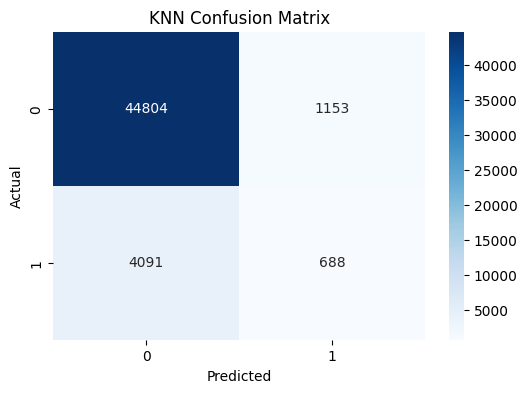

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the KNN model
# A common starting point for n_neighbors is 5.
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_processed, y_train)

print("K-Nearest Neighbors model trained successfully!")

# Make predictions on the processed test data
y_pred_knn = knn_model.predict(X_test_processed)

# Calculate individual metrics
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print(f"\n### KNN Evaluation Metrics ###")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")

print("\n### KNN Confusion Matrix ###")
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model Training and Evaluation: SVM

Training Decision Tree model...
Decision Tree model trained successfully!

### Decision Tree Evaluation Metrics ###
Accuracy: 0.8523
Precision: 0.2436
Recall: 0.2699
F1-Score: 0.2561

### Decision Tree Confusion Matrix ###


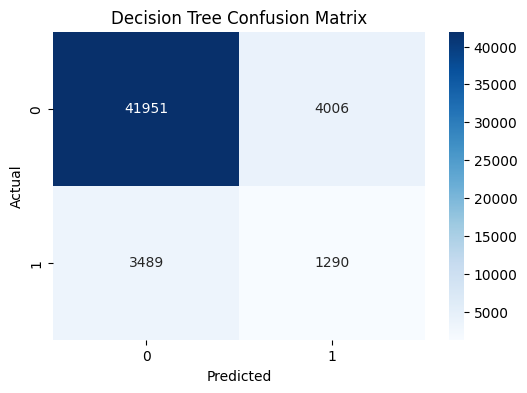

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
print("Training Decision Tree model...")
decision_tree_model.fit(X_train_processed, y_train)

print("Decision Tree model trained successfully!")

# Make predictions on the processed test data
y_pred_dt = decision_tree_model.predict(X_test_processed)

# Calculate individual metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print(f"\n### Decision Tree Evaluation Metrics ###")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")

print("\n### Decision Tree Confusion Matrix ###")
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Training Random Forest model...
Random Forest model trained successfully!

### Random Forest Evaluation Metrics ###
Accuracy: 0.9005
Precision: 0.4030
Recall: 0.1174
F1-Score: 0.1818

### Random Forest Confusion Matrix ###


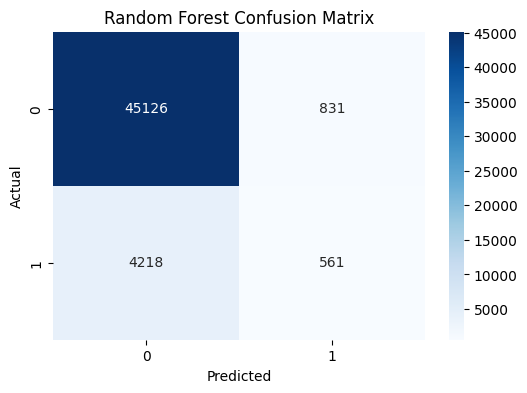

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
print("Training Random Forest model...")
rf_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully!")

# Make predictions on the processed test data
y_pred_rf = rf_model.predict(X_test_processed)

# Calculate individual metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"\n### Random Forest Evaluation Metrics ###")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

print("\n### Random Forest Confusion Matrix ###")
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



We have trained and evaluated three different classification algorithms: K-Nearest Neighbors (KNN), Decision Tree, and Random Forest. Given the imbalanced nature of our target variable (HeartDiseaseorAttack, with a low percentage of positive cases), metrics beyond simple accuracy, such as Precision, Recall, and F1-Score, are crucial for a comprehensive understanding of model performance.

---

### K-Nearest Neighbors (KNN) Insights

KNN is a non-parametric, instance-based learning algorithm. It classifies a data point based on how its neighbors are classified. In our case, the model looks at the 'k' nearest data points in the feature space to make a prediction.

*   **Accuracy: 0.8966** - KNN shows a relatively high overall accuracy, largely due to correctly classifying the majority class (no heart disease).
*   **Precision: 0.3737** - When KNN predicts someone has heart disease, it is correct about 37.37% of the time. This means there are a significant number of false positives.
*   **Recall: 0.1440** - The model only correctly identifies about 14.40% of all actual heart disease cases. This is quite low, indicating that many individuals with heart disease are being missed (false negatives).
*   **F1-Score: 0.2079** - The F1-Score, which is the harmonic mean of precision and recall, is low, reflecting the poor balance between precision and recall.
*   **Confusion Matrix Analysis:** The large number of False Negatives (4091) confirms the model's struggle to detect the positive class. While it correctly identifies a large number of negative cases (~44804), its ability to find actual positive cases is limited.

**Overall Insight:** KNN, in its basic form, appears to be heavily biased towards the majority class, resulting in high accuracy but very poor recall for heart disease prediction. This is generally undesirable in medical diagnostics where missing positive cases (false negatives) can have serious consequences.

---

### Decision Tree Insights

A Decision Tree builds a model of decisions and their possible consequences in a tree-like structure. It splits the data based on features to make predictions.

*   **Accuracy: 0.8523** - The accuracy is lower than KNN and Random Forest, suggesting more overall misclassifications.
*   **Precision: 0.2436** - When a Decision Tree predicts heart disease, it's correct only about 24.36% of the time, indicating many false positives.
*   **Recall: 0.2699** - The model identifies about 26.99% of actual heart disease cases. While still low, it's significantly better than KNN's recall. This means it catches more positive cases, but at the cost of higher false positives (lower precision).
*   **F1-Score: 0.2561** - The F1-Score is slightly higher than KNN, suggesting a somewhat better balance between precision and recall, though still far from ideal.
*   **Confusion Matrix Analysis:** Compared to KNN, the Decision Tree has fewer False Negatives (3489) but more False Positives (4006), illustrating the trade-off. It's doing a better job at identifying positive cases but also making more incorrect positive predictions.

**Overall Insight:** The Decision Tree with class balancing improved recall compared to KNN, indicating it's less prone to missing positive cases. However, its overall predictive power is still moderate, with considerable false positives and a modest F1-score. Decision Trees can also be prone to overfitting.

---

### Random Forest Insights

Random Forest is an ensemble learning method that constructs a multitude of decision trees during training and outputs the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. It often reduces overfitting compared to a single decision tree.

*   **Accuracy: 0.9005** - Random Forest achieves the highest accuracy among the three models tested so far.
*   **Precision: 0.4030** - This is the highest precision achieved, meaning that when the Random Forest predicts heart disease, it is correct approximately 40.30% of the time. This is better than both KNN and Decision Tree, implying fewer false positives.
*   **Recall: 0.1174** - Unfortunately, the recall for Random Forest is the lowest among the three models. It only identifies about 11.74% of actual heart disease cases, meaning it misses the most positive cases.
*   **F1-Score: 0.1818** - The F1-Score is the lowest, primarily driven by the very low recall. Despite higher precision, the inability to capture a significant portion of positive cases drags this metric down.
*   **Confusion Matrix Analysis:** Random Forest has the highest number of True Negatives (45126) and the lowest number of False Positives (~831), which explains its high accuracy and precision. However, it also has the highest number of False Negatives (4218), indicating its weakness in identifying the minority class.

**Overall Insight:** Random Forest demonstrates strong performance in correctly identifying individuals *without* heart disease and making few false positive predictions. However, its very low recall makes it a poor choice for a medical diagnostic scenario where missing actual heart disease cases (false negatives) is a critical concern. Its strength lies in avoiding false alarms, but at the expense of detection sensitivity.